# Edge Detection in Image Processing
### Simple Gradient, Sobel, Laplacian, and Canny

This notebook introduces basic **edge detection techniques** used in image processing.

Students will learn:
- Simple gradient edge detection
- Sobel operator
- Laplacian operator
- Canny edge detector

These methods are fundamental in **computer vision**, **medical imaging**, and **AI-based image analysis**.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Import Required Libraries
We use:
- `OpenCV` for image processing
- `NumPy` for numerical operations
- `Matplotlib` for visualization

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## 2. Load an Image

You can either:
- Upload your own image in Colab
- Or use the sample image below.

(np.float64(-0.5), np.float64(1439.5), np.float64(1109.5), np.float64(-0.5))

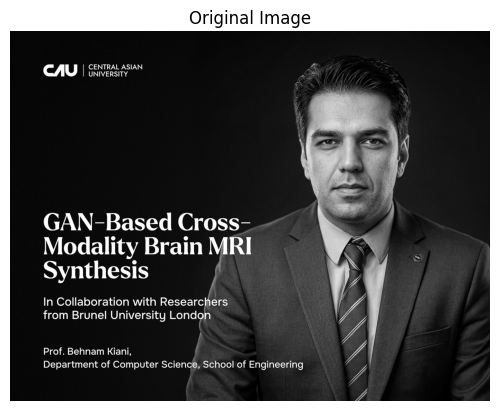

In [ ]:
# If running in Google Colab, uncomment below to upload an image
# from google.colab import files
# uploaded = files.upload()

# Load example image from internet
import urllib.request

url = 'https://static.tildacdn.com/tild6530-6465-4134-a165-373062643564/Centralasianuz_news_.jpg'
urllib.request.urlretrieve(url, 'image.png')

image = cv2.imread('image.png')
image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

## 3. Simple Gradient Edge Detection

Edges correspond to **rapid intensity changes**.

A simple way to detect edges is by computing gradients in the **x** and **y** directions.

(np.float64(-0.5), np.float64(1439.5), np.float64(1109.5), np.float64(-0.5))

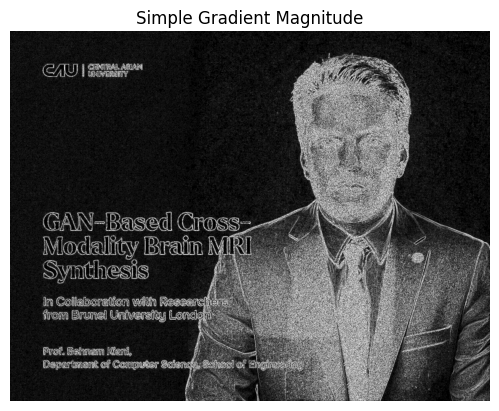

In [ ]:
gx = np.zeros_like(image)
gy = np.zeros_like(image)

gx[:, :-1] = np.diff(image, axis=1)
gy[:-1, :] = np.diff(image, axis=0)

gradient_magnitude = np.sqrt(gx**2 + gy**2)

plt.imshow(gradient_magnitude, cmap='gray')
plt.title('Simple Gradient Magnitude')
plt.axis('off')

## 4. Sobel Edge Detector

The **Sobel operator** computes gradients using convolution kernels.

It detects:
- Horizontal edges
- Vertical edges

# Sobel Edge Detection – Complete Guide

The **Sobel operator** is a first-order derivative method used to detect **edges in specific directions** (horizontal or vertical).  
It calculates the gradient of image intensity using **convolution with Sobel kernels**.

Unlike the Laplacian, which detects edges in all directions, the Sobel operator can detect:

- **Horizontal edges** (changes along the y-axis)  
- **Vertical edges** (changes along the x-axis)

---

## 1. OpenCV Function

In OpenCV, Sobel is implemented as:

```python
sobel = cv2.Sobel(src, ddepth, dx, dy[, ksize[, scale[, delta[, borderType]]]])

## Sobel Function Arguments

| Argument      | Description |
|---------------|-------------|
| `src`         | Input image (grayscale or color). |
| `ddepth`      | Desired depth of the output image (e.g., `cv2.CV_64F` to avoid overflow). |
| `dx`          | Order of the derivative in the x direction. Use 1 for horizontal gradients. |
| `dy`          | Order of the derivative in the y direction. Use 1 for vertical gradients. |
| `ksize`       | (Optional) Size of the extended Sobel kernel. Must be **odd** (1, 3, 5, 7). Default = 3. |
| `scale`       | (Optional) Optional scale factor applied to the computed derivative values. Default = 1. |
| `delta`       | (Optional) Optional value added to the results before storing in output. Default = 0. |
| `borderType`  | (Optional) Pixel extrapolation method at borders. Default = `cv2.BORDER_DEFAULT`. |

(np.float64(-0.5), np.float64(1439.5), np.float64(1109.5), np.float64(-0.5))

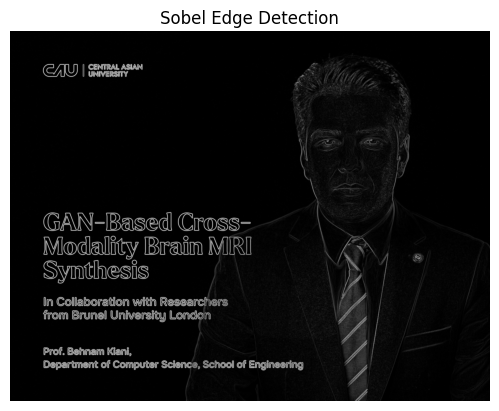

In [ ]:
sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)

sobel_magnitude = np.sqrt(sobel_x**2 + sobel_y**2)

plt.imshow(sobel_magnitude, cmap='gray')
plt.title('Sobel Edge Detection')
plt.axis('off')

## 5. Laplacian Edge Detection

The **Laplacian operator** detects edges by computing the **second derivative** of the image.

It highlights regions where intensity changes rapidly.

# Laplacian Edge Detection – Complete Guide

The **Laplacian operator** is a second-order derivative method used to detect edges in an image.  
It highlights areas where the **intensity changes rapidly**, such as edges, corners, or boundaries.

Unlike Sobel or simple gradients, which detect edges in **specific directions (x or y)**, the Laplacian is **isotropic**, meaning it detects edges in **all directions**.

---

## 1. OpenCV Function

In OpenCV, the Laplacian is implemented as:

```python
laplacian = cv2.Laplacian(src, ddepth[, dst[, ksize[, scale[, delta[, borderType]]]]])

## Laplacian Function Arguments

| Argument      | Description |
|---------------|-------------|
| `src`         | Input image (grayscale or color). |
| `ddepth`      | Desired depth of the output image (e.g., `cv2.CV_64F` to avoid overflow). |
| `dst`         | (Optional) Output image of the same size as input. |
| `ksize`       | (Optional) Kernel size for the Laplacian filter. Must be **odd** (1, 3, 5, 7). Default = 1. |
| `scale`       | (Optional) Optional scale factor applied to the computed Laplacian values. Default = 1. |
| `delta`       | (Optional) Optional value added to the result before storing in `dst`. Default = 0. |
| `borderType`  | (Optional) Pixel extrapolation method at borders. Default = `cv2.BORDER_DEFAULT`. |

(np.float64(-0.5), np.float64(1439.5), np.float64(1109.5), np.float64(-0.5))

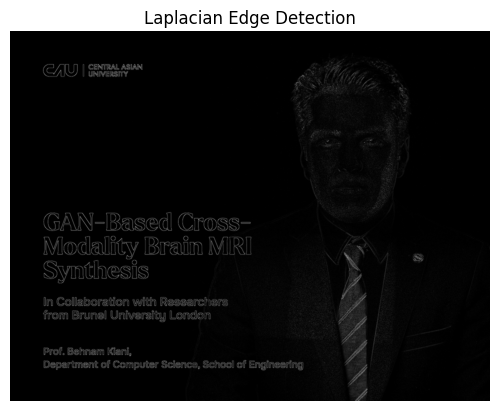

In [ ]:
laplacian = cv2.Laplacian(image, cv2.CV_64F)

plt.imshow(np.abs(laplacian), cmap='gray')
plt.title('Laplacian Edge Detection')
plt.axis('off')

## 6. Canny Edge Detector

The **Canny algorithm** is one of the most powerful edge detection techniques.

Steps:
1. Noise reduction (Gaussian blur)
2. Gradient calculation
3. Non‑maximum suppression
4. Double threshold
5. Edge tracking by hysteresis

# Canny Edge Detection – Complete Guide

The **Canny Edge Detector** is one of the most widely used edge detection algorithms in **image processing** and **computer vision**. It was developed by **John F. Canny (1986)** with the goal of detecting edges **accurately**, **robustly**, and **with minimal noise sensitivity**.

Unlike simple gradient-based operators (like Sobel or Laplacian), Canny is a **multi-stage algorithm** designed to produce **thin, continuous, and well-localized edges**.

---

## 1. OpenCV Function

In OpenCV, the Canny edge detector is implemented as:

```python
edges = cv2.Canny(image, threshold1, threshold2[, edges[, apertureSize[, L2gradient]]])

## Canny Function Arguments

| Argument       | Description |
|----------------|-------------|
| `image`        | Input image (must be **single-channel grayscale**). |
| `threshold1`   | Lower threshold for the hysteresis procedure. Pixels with gradient **below this are rejected**. |
| `threshold2`   | Upper threshold for hysteresis. Pixels **above this are considered strong edges**. |
| `edges`        | (Optional) Output image; same size and type as input. |
| `apertureSize` | (Optional) Size of the Sobel kernel used for gradient calculation. Typical values: **3, 5, 7**. Default = 3. |
| `L2gradient`   | (Optional) Boolean flag. If `True`, gradient magnitude is computed using **√(Gx² + Gy²)** for higher accuracy. Default = `False` (approximated with |Gx| + |Gy|). |

(np.float64(-0.5), np.float64(1439.5), np.float64(1109.5), np.float64(-0.5))

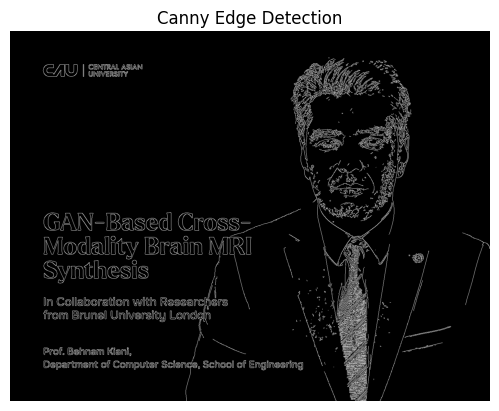

In [ ]:
canny = cv2.Canny(image, 100, 200)

plt.imshow(canny, cmap='gray')
plt.title('Canny Edge Detection')
plt.axis('off')

## 7. Comparison of All Methods

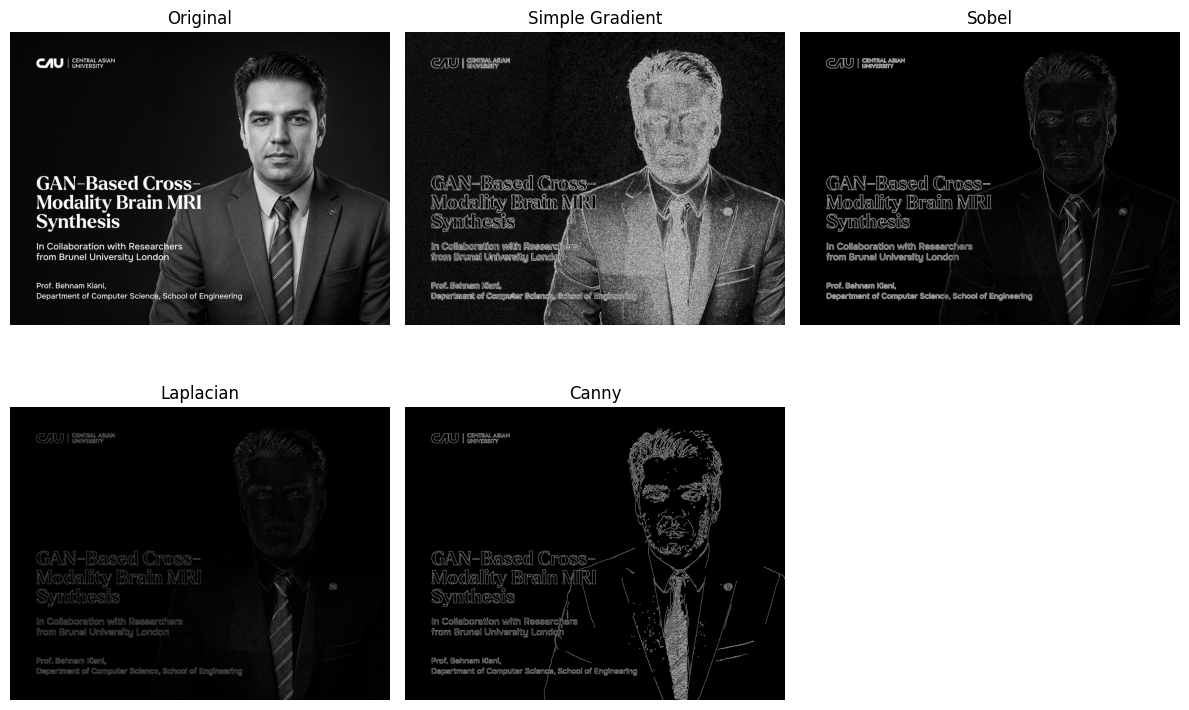

In [ ]:
plt.figure(figsize=(12,8))

plt.subplot(2,3,1)
plt.imshow(image, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(gradient_magnitude, cmap='gray')
plt.title('Simple Gradient')
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(sobel_magnitude, cmap='gray')
plt.title('Sobel')
plt.axis('off')

plt.subplot(2,3,4)
plt.imshow(np.abs(laplacian), cmap='gray')
plt.title('Laplacian')
plt.axis('off')

plt.subplot(2,3,5)
plt.imshow(canny, cmap='gray')
plt.title('Canny')
plt.axis('off')

plt.tight_layout()
plt.show()

## 8. Exercises for Students

1. Change the **Canny thresholds** and observe the effect.
2. Apply **Gaussian blur** before Sobel and Laplacian.
3. Test different images (medical images, natural images).
4. Compare which method detects edges **more clearly**.

Discussion questions:
- Which method is more sensitive to noise?
- Why is Canny considered a multi‑stage detector?

## 1. Change the Canny thresholds and observe the effect.

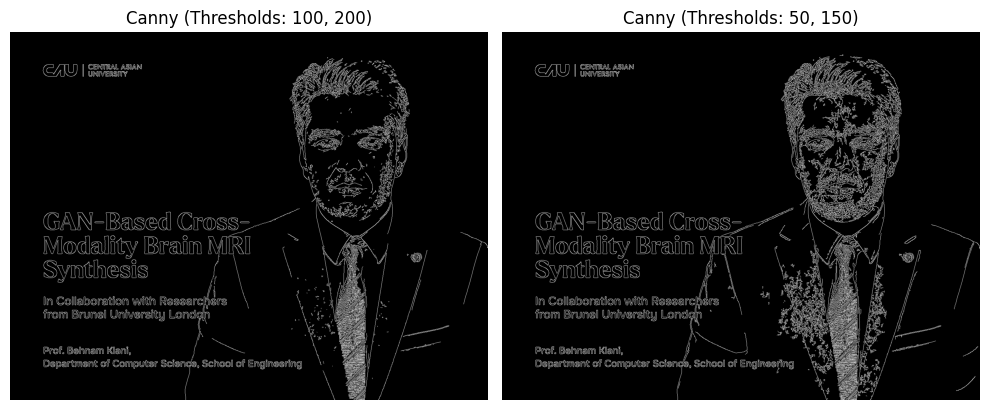

In [ ]:
canny_new_thresholds = cv2.Canny(image, 50, 150)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(canny, cmap='gray')
plt.title('Canny (Thresholds: 100, 200)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(canny_new_thresholds, cmap='gray')
plt.title('Canny (Thresholds: 50, 150)')
plt.axis('off')

plt.tight_layout()
plt.show()

## 2.Apply Gaussian blur before Sobel and Laplacian.

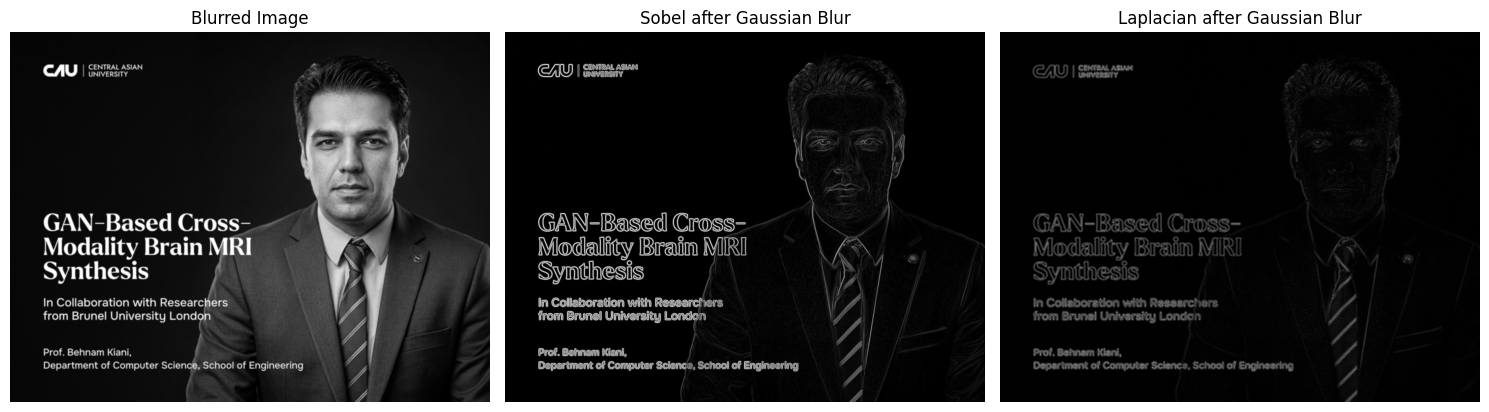

In [ ]:
blurred_image = cv2.GaussianBlur(image, (5, 5), 0)

sobel_x_blurred = cv2.Sobel(blurred_image, cv2.CV_64F, 1, 0, ksize=3)
sobel_y_blurred = cv2.Sobel(blurred_image, cv2.CV_64F, 0, 1, ksize=3)
sobel_magnitude_blurred = np.sqrt(sobel_x_blurred**2 + sobel_y_blurred**2)

laplacian_blurred = cv2.Laplacian(blurred_image, cv2.CV_64F)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(blurred_image, cmap='gray')
plt.title('Blurred Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(sobel_magnitude_blurred, cmap='gray')
plt.title('Sobel after Gaussian Blur')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(np.abs(laplacian_blurred), cmap='gray')
plt.title('Laplacian after Gaussian Blur')
plt.axis('off')

plt.tight_layout()
plt.show()

## 3.Test different images (medical images, natural images).

Processing new natural image...


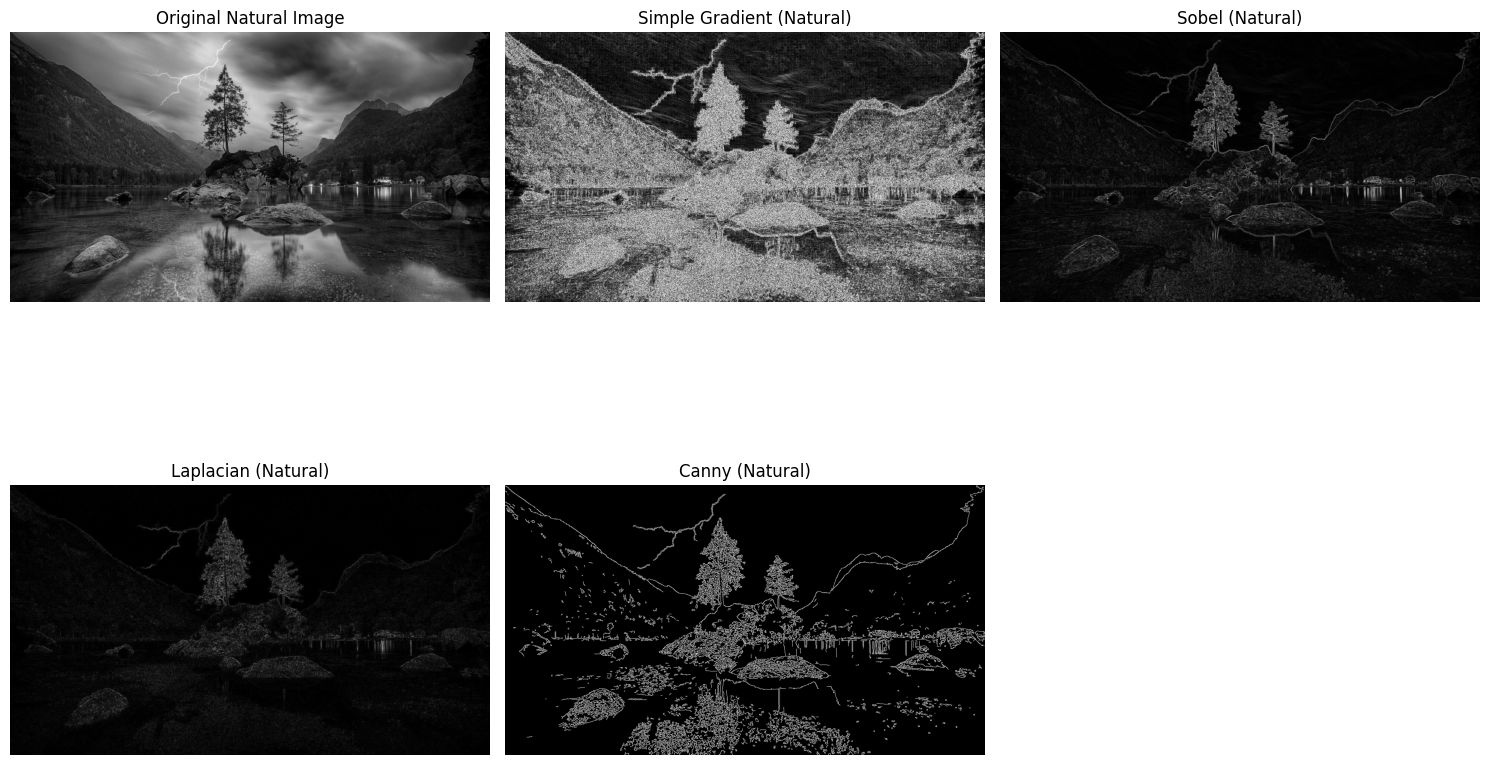

In [ ]:
# --- Test with a new Natural Image ---
print('Processing new natural image...')

natural_image = cv2.imread('/content/drive/MyDrive/Lab 8/nature.jpg')
natural_image = cv2.cvtColor(natural_image, cv2.COLOR_BGR2GRAY)

# Simple Gradient
gx_nat = np.zeros_like(natural_image)
gy_nat = np.zeros_like(natural_image)
gx_nat[:, :-1] = np.diff(natural_image, axis=1)
gy_nat[:-1, :] = np.diff(natural_image, axis=0)
gradient_magnitude_nat = np.sqrt(gx_nat**2 + gy_nat**2)

# Sobel
sobel_x_nat = cv2.Sobel(natural_image, cv2.CV_64F, 1, 0, ksize=3)
sobel_y_nat = cv2.Sobel(natural_image, cv2.CV_64F, 0, 1, ksize=3)
sobel_magnitude_nat = np.sqrt(sobel_x_nat**2 + sobel_y_nat**2)

# Laplacian
laplacian_nat = cv2.Laplacian(natural_image, cv2.CV_64F)

# Canny
canny_nat = cv2.Canny(natural_image, 100, 200)

plt.figure(figsize=(15, 10))

plt.subplot(2,3,1)
plt.imshow(natural_image, cmap='gray')
plt.title('Original Natural Image')
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(gradient_magnitude_nat, cmap='gray')
plt.title('Simple Gradient (Natural)')
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(sobel_magnitude_nat, cmap='gray')
plt.title('Sobel (Natural)')
plt.axis('off')

plt.subplot(2,3,4)
plt.imshow(np.abs(laplacian_nat), cmap='gray')
plt.title('Laplacian (Natural)')
plt.axis('off')

plt.subplot(2,3,5)
plt.imshow(canny_nat, cmap='gray')
plt.title('Canny (Natural)')
plt.axis('off')

plt.tight_layout()
plt.show()


Processing medical image...


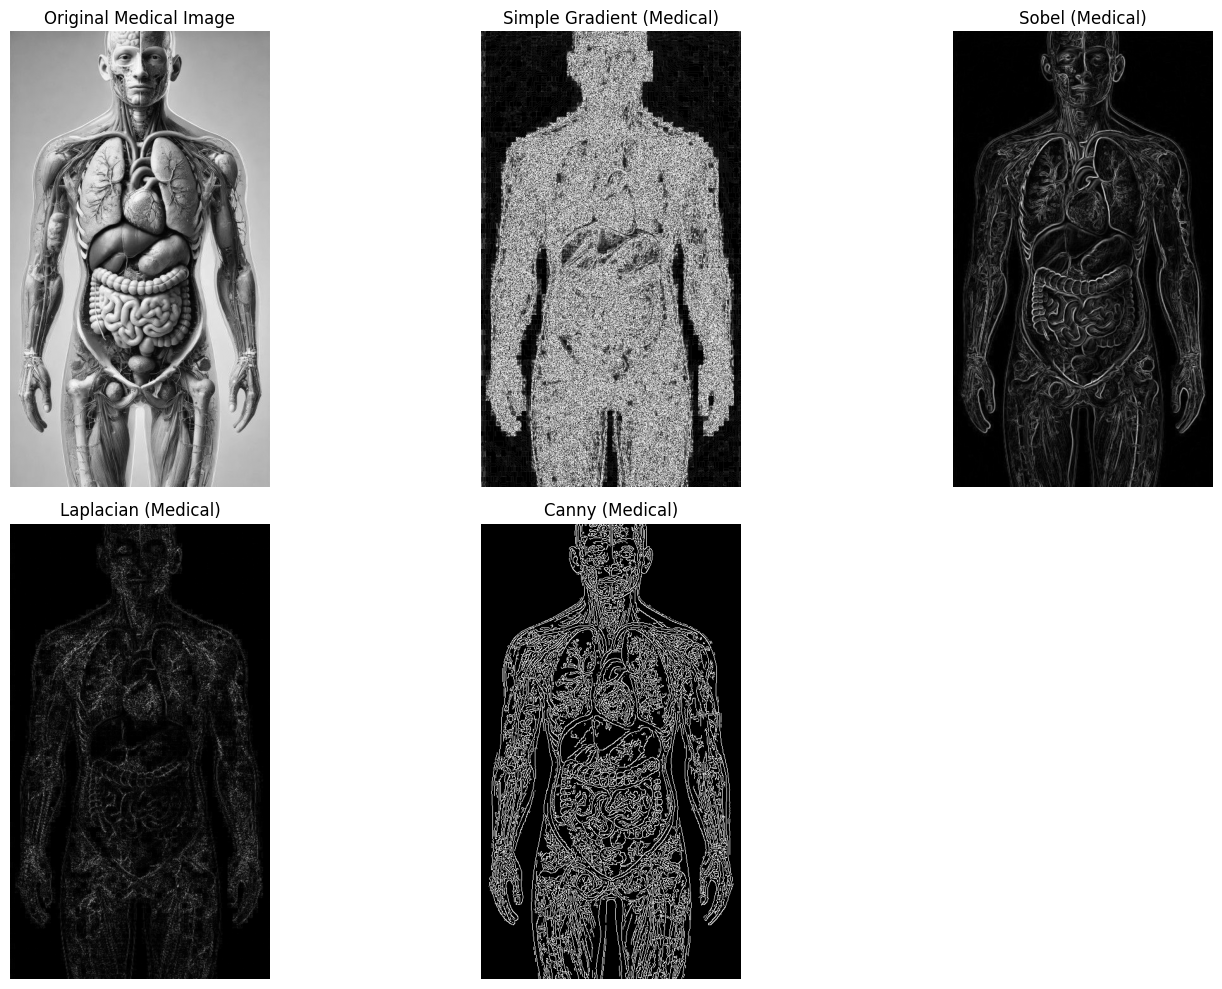

In [ ]:
# --- Test with a Medical Image (Placeholder) ---
print('Processing medical image...')

medical_image = cv2.imread('/content/drive/MyDrive/Lab 8/skeleton.jpg')
medical_image = cv2.cvtColor(medical_image, cv2.COLOR_BGR2GRAY)

# Simple Gradient
gx_med = np.zeros_like(medical_image)
gy_med = np.zeros_like(medical_image)
gx_med[:, :-1] = np.diff(medical_image, axis=1)
gy_med[:-1, :] = np.diff(medical_image, axis=0)
gradient_magnitude_med = np.sqrt(gx_med**2 + gy_med**2)

# Sobel
sobel_x_med = cv2.Sobel(medical_image, cv2.CV_64F, 1, 0, ksize=3)
sobel_y_med = cv2.Sobel(medical_image, cv2.CV_64F, 0, 1, ksize=3)
sobel_magnitude_med = np.sqrt(sobel_x_med**2 + sobel_y_med**2)

# Laplacian
laplacian_med = cv2.Laplacian(medical_image, cv2.CV_64F)

# Canny
canny_med = cv2.Canny(medical_image, 50, 150) # Using slightly different thresholds for medical image

plt.figure(figsize=(15, 10))

plt.subplot(2,3,1)
plt.imshow(medical_image, cmap='gray')
plt.title('Original Medical Image')
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(gradient_magnitude_med, cmap='gray')
plt.title('Simple Gradient (Medical)')
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(sobel_magnitude_med, cmap='gray')
plt.title('Sobel (Medical)')
plt.axis('off')

plt.subplot(2,3,4)
plt.imshow(np.abs(laplacian_med), cmap='gray')
plt.title('Laplacian (Medical)')
plt.axis('off')

plt.subplot(2,3,5)
plt.imshow(canny_med, cmap='gray')
plt.title('Canny (Medical)')
plt.axis('off')

plt.tight_layout()
plt.show()
